# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Jingyi Chen, Zixuan Deng, Xuefei Sun*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [15]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [16]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


# Introduction

This dataset is from the UNICEF Malawi Survey and contains information on children's demographics, education, family conditions and well-being.  

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

# Exploratory Data Analysis and Feature Engineering
The data used in this study is sourced from the UNICEF Malawi Survey, aiming to predict an children's tendencies towards depression through multiple indicators such as family environment and personal education.  

*1. Data Discussion*  

Filter out the necessary variables from unicef_malawi.csv as follows:  

Family background:  
Wealth Score (wscore): This is a comprehensive index that reflects the possession of family assets (such as housing materials, durable consumer goods). In resource-scarce regions, a low wealth score is usually positively correlated with higher survival anxiety.  
Sanitation Facilities and water Resources (WS4, WS15, WS7): The duration of water collection reflects the degree of infrastructure improvement and the burden of household labor. Shared toilets (WS15) and insufficient drinking water (WS7) not only affect physical health, but also are important sources of a sense of dignity in life and psychological stress.  
Health Protection (TN1): The number of mosquito nets is a proxy indicator of malaria prevention capacity. In areas with a high incidence of malaria, the lack of health security will significantly increase the psychological burden on family members.  

Violent tendencies:  
Mother's Attitude towards domestic Violence (DV1A-E): It includes five detailed scenario descriptions of "under what circumstances a husband can hit his wife". If respondents choose "YES" in multiple scenarios, it reflects their internalization and tolerance of violent behavior, and perhaps they will pass on this suppressed pressure to their children.  
Tendency towards corporal punishment of children (FCD2A-K & FCD5): It records various forms of punishment that parents have adopted against their children in the past month (ranging from verbal humiliation to severe corporal punishment). Frequent corporal punishment not only reflects the loss of control of parents' emotional management, but also is a manifestation that can cause depression in children.  

Educational level and social attributes:  
Educational attainment (CB5A & CB7, WB6A): It distinguishes the highest academic qualifications of children and mothers. Individuals with lower educational levels often lack effective coping mechanisms when facing life's challenges and have fewer job opportunities, thus being more prone to depression.  
Marriage and family structure (MSTATUS, MA3, CSURV): Marital status (whether married, whether in a polygamous family) may affect a mother's psychology and thus be reflected in her children.  
The number of children (CSURV) reflects the burden of raising children. Under conditions of limited resources, having too many children may lead to significant economic and psychological stress.  
Mother's satisfaction with life (LS1) : If the mother is dissatisfied with her current life, it indicates that the family is under great pressure and it may affect the child.  

Children's labor time:  
Children's labor indicators (CL2, CL3, CL12, CL13): Record the time children spend on household chores or paid labor. When families are forced to rely on children's labor to make a living, it is usually accompanied by deep anxiety and depression risks for the children.  

Although variables related to fathers were initially considered, they were excluded due to the large amount of missing data. The Male Questionnaire only included a portion of men, resulting in a coverage rate of less than 2% in our dataset. Including these variables will significantly reduce the sample size and introduce selection bias. Therefore, we focus on children, mothers and family characteristics.


The target variable of this study is depression, which was constructed from the questionnaire survey question FCF26.


In [17]:
main= pd.read_csv('unicef_malawi.csv')
#Selected needed variables
selected_from_main = [
    'HH1', 'HH2', 'LN', #Basic links          
    'CB3', #Children ages
    'CB7', #Still at school or not
    'CB5A', #Education level (children)
    'CL2', 'CL3', 'CL12', 'CL13', #Child Labour
    'FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K', 
    'FCD5', #Physical punishment
    'FCF26', #Depression
    'wscore', #Comprehensive wealth score
    'TN1', #Number of moaquito nets
    'WS4', #Time of fectching water
    'WS7', #Insufficient drinking water
    'WS15', #Share toilet with others
    'WB6A', #Education level
    'LS1', #Life satisfaction
    'DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E', #Attutude towards domestic violence
    'MA3', #Husband has another wife or not
    'MSTATUS', #Marrige
    'CSURV' #Number of children
]
existing = [col for col in selected_from_main if col in main.columns]
main = main[existing].copy()
print(main.columns.tolist())
main.info()
main.describe()

['HH1', 'HH2', 'LN', 'CB3', 'CB7', 'CB5A', 'CL2', 'CL3', 'CL12', 'CL13', 'FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K', 'FCD5', 'FCF26', 'wscore', 'TN1', 'WS4', 'WS7', 'WS15', 'WB6A', 'LS1', 'DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E', 'MA3', 'MSTATUS', 'CSURV']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 38 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   HH1      13162 non-null  float64
 1   HH2      13162 non-null  float64
 2   LN       13162 non-null  float64
 3   CB3      13059 non-null  float64
 4   CB7      12203 non-null  object 
 5   CB5A     12203 non-null  object 
 6   CL2      13162 non-null  bool   
 7   CL3      4159 non-null   float64
 8   CL12     13162 non-null  bool   
 9   CL13     11092 non-null  object 
 10  FCD2A    11264 non-null  object 
 11  FCD2B    11264 non-null  object 
 12  FCD2C    11264 non-null  object 
 13  FCD2D 

,HH1,HH2,LN,CB3,CL3,wscore,CSURV
count,13162.000000,13162.000000,13162.000000,13059.000000,4159.000000,13162.000000,13162.000000
mean,552.937623,12.708327,1.751633,9.853817,4.318586,0.027097,3.746999
std,320.588443,7.278076,0.565388,3.588369,7.204110,0.990625,1.804803
min,1.000000,1.000000,1.000000,5.000000,0.000000,-1.302800,0.000000
25%,273.000000,7.000000,1.000000,7.000000,1.000000,-0.632998,2.000000
50%,554.000000,13.000000,2.000000,9.000000,2.000000,-0.320947,4.000000
75%,830.000000,19.000000,2.000000,13.000000,5.000000,0.267699,5.000000
max,1112.000000,60.000000,10.000000,17.000000,77.000000,5.337324,12.000000


This dataset contains 13,162 original samples, covering 38 variables. According to the initial examination, the variables are mainly classified into three categories: ID identifiers (such as HH1, HH2, LN), continuous numerical variables (such as family wealth wscore, age CB3), and classification/Boolean variables (such as mother's educational level WB6A, child's labor status CL2).

In [18]:
#Construct binary variable on FCF26
main = main[main['FCF26'].notna()].copy()
main['depression'] = main['FCF26'].apply(
    lambda x: 0 if x == 'NEVER' else 1)
print(main['depression'].value_counts())
print(main['depression'].value_counts(normalize=True))

depression
1    7154
0    5905
Name: count, dtype: int64
depression
1    0.547821
0    0.452179
Name: proportion, dtype: float64


It can be seen that the target variables are relatively balanced, with approximately 55% of the children having some degree of depressive symptoms.

*2. Train/Test Split*  
To prevent data leakage, the dataset is divided into a training set (80%) and a test set (20%) before conducting a detailed exploratory analysis.

In [19]:
from sklearn.model_selection import train_test_split
#Delete original depression column and new 
X = main.drop(columns=['FCF26', 'depression'])
y = main['depression']
#Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"shape of training set: {X_train.shape}")
print(f"shape of testing set: {X_test.shape}")
print(f"depression proportion of training set: {y_train.mean():.3f}")
print(f"depression proportion of testing set: {y_test.mean():.3f}")
#Delete basic links
id_cols = ['HH1', 'HH2', 'LN']
X_train = X_train.drop(columns=id_cols, errors='ignore')
X_test = X_test.drop(columns=id_cols, errors='ignore')
print("After deleting", X_train.shape[1])

shape of training set: (10447, 37)
shape of testing set: (2612, 37)
depression proportion of training set: 0.548
depression proportion of testing set: 0.548
After deleting 34


*3. Missing Data*  
Before establishing a predictive model, it is first necessary to evaluate the integrity of the feature matrix. We calculated the missing ratio of each feature in the training set and extracted the top 15 variables with the highest missing rates for visualization.

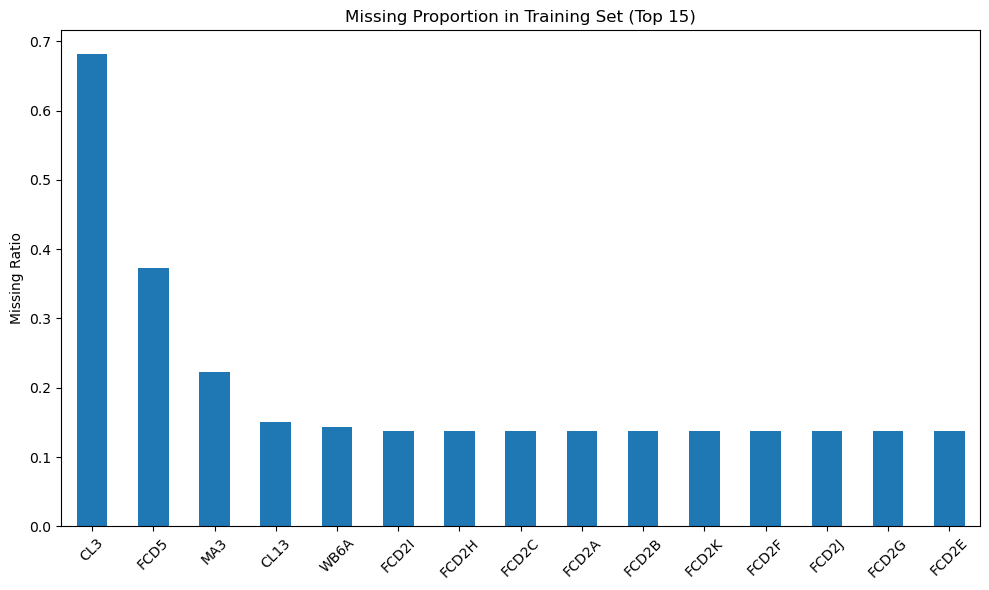

In [20]:
missing_ratio = X_train.isnull().mean().sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]
plt.figure(figsize=(10,6))
missing_ratio.head(15).plot(kind='bar')
plt.title('Missing Proportion in Training Set (Top 15)')
plt.ylabel('Missing Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As can be seen from the above figure, the missing rate of CL3 is approximately 68%, which is a relatively large proportion. Consider generating a new CL3\_missing value during preprocess. Because in the context of the questionnaire, the absence of this variable is usually not random but indicates that the family has no children participating in labor. Therefore, by introducing this binary feature, the subsequent model can not only learn the impact of labor intensity on depression through the media-filled CL3, but also capture the mental health differences among children without labor records through CL3\_missing. The remaining missing numerical variables are filled with the median, and the categorical variables are filled with the mode, and these are implemented in the Pipeline.

*4. Distribution of numerical data*  
This section mainly conducts statistical distribution analysis on numerical characteristics, with a focus on three core continuous variables: the age of the interviewed children (CB3), the number of surviving children in the family (CSURV), and the comprehensive wealth score (wscore).


Summary statistics for CB3:
count    10447.000000
mean         9.861013
std          3.595450
min          5.000000
25%          7.000000
50%          9.000000
75%         13.000000
max         17.000000
Name: CB3, dtype: float64


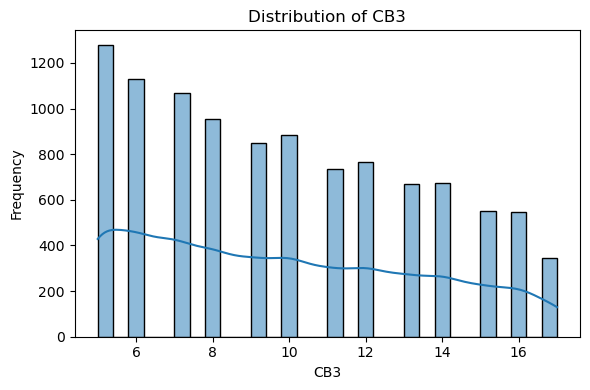


Summary statistics for CSURV:
count    10447.000000
mean         3.758304
std          1.810808
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         12.000000
Name: CSURV, dtype: float64


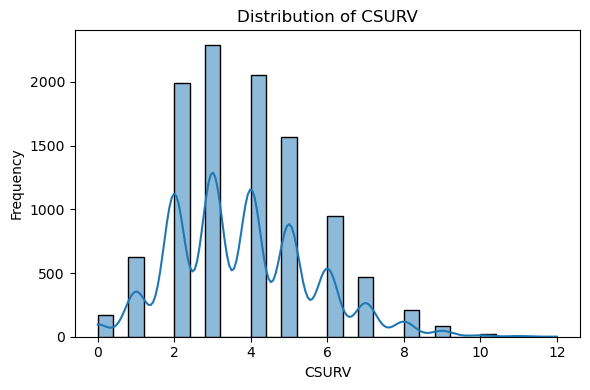


Summary statistics for wscore:
count    10447.000000
mean         0.029275
std          0.994478
min         -1.302800
25%         -0.633861
50%         -0.324383
75%          0.280942
max          5.337324
Name: wscore, dtype: float64


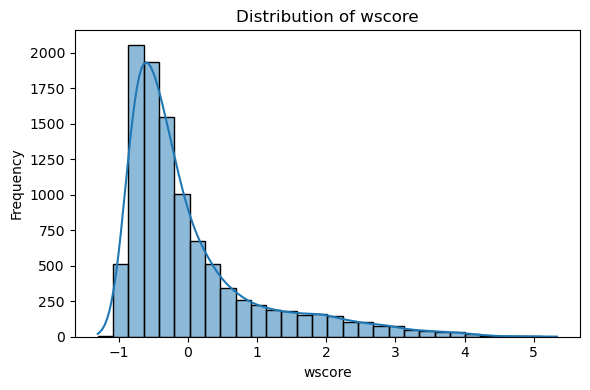

In [21]:
#Select numeric features
num_features = ['CB3', 'CSURV', 'wscore']

for col in num_features:
    if col in X_train.columns:
        #Print summary statistics
        print(f"\nSummary statistics for {col}:")
        print(X_train[col].describe())       
        #Plot histogram
        plt.figure(figsize=(6,4))
        sns.histplot(X_train[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

From the above statistical description and histogram chart, it can be seen that CB3 is generally distributed between the ages of 5 and 17, which is relatively uniform. CRUSV, on the other hand, indicates the relatively high fertility rate in the local area, with people generally choosing to have 2 to 4 children. The wscore shows an overall right-skewed phenomenon, indicating that the wealth situation of local families is not optimistic and there is a significant gap between the rich and the poor, suggesting that these variables need to be appropriately scaled

*5. Relationship between other features and depression*  

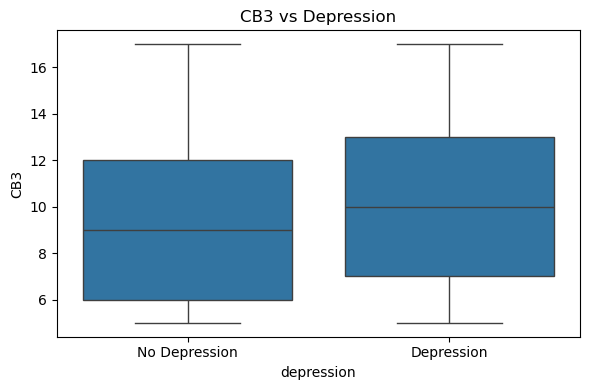

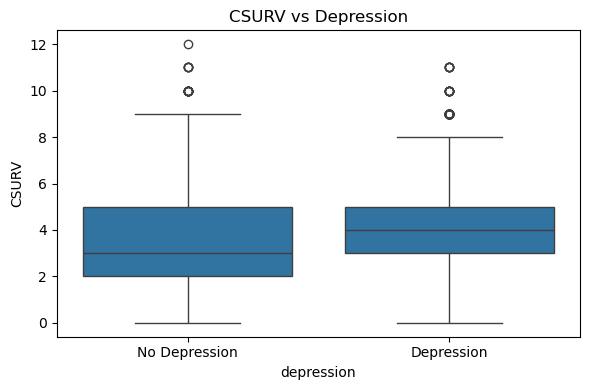

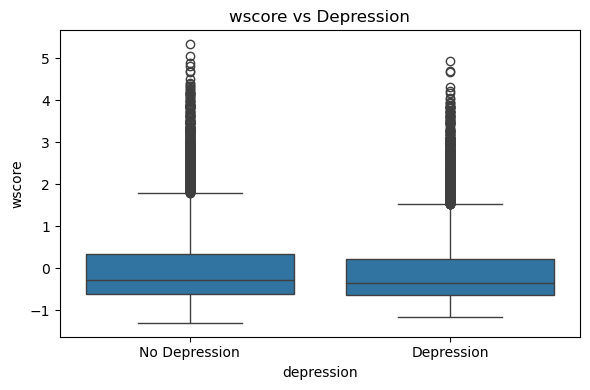

In [22]:
num_features = ['CB3', 'CSURV', 'wscore']
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y_train, y=X_train[col])
    plt.xticks([0,1], ['No Depression', 'Depression'])
    plt.title(f'{col} vs Depression')
    plt.tight_layout()
    plt.show()

From the above boxplot, it can be concluded that in terms of CB3, the older the child, the more likely they are to have a tendency towards depression. This might be due to the increased family and labor burdens that teenagers face after entering adolescence. CRUSV shows that the more children a family has, the more prone it is to depression. This might be due to the excessive family burden, requiring older children to do labor, which causes psychological pressure on the children. wscore indicates that the poorer the family, the more likely children are to develop depressive thoughts. This might be due to the fact that a poor family requires more labor, or that both parents are engaged in labor without providing proper guidance and companionship for their children's growth.

*6. Analysis of FCD2 and DV1*  
Calculate the depression rate based on different indicators, then provide a decision on how to dealing with these indicators.

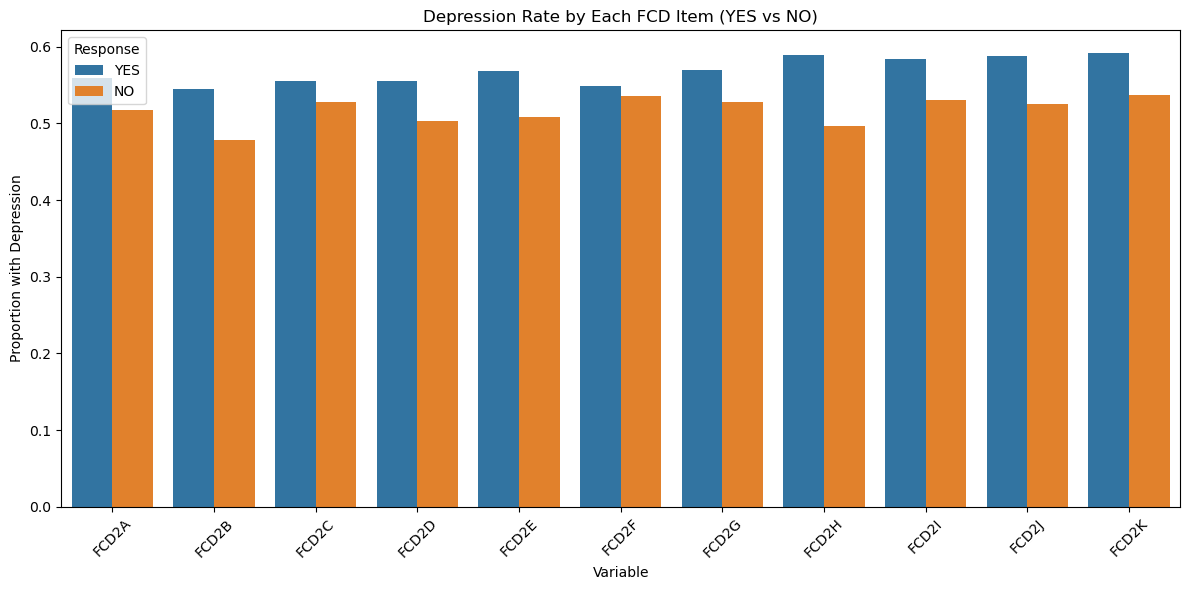

In [23]:
fcd_cols = ['FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 
            'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

#Define a function to calculate the depression rate of each variable in the YES/NO group
def compute_depression_rate_by_response(df, col, y):
    rates = []
    for response in ['YES', 'NO']:
        mask = (df[col] == response)
        if mask.any():
            rate = y[mask].mean()
        else:
            rate = np.nan
        rates.append({'Variable': col, 'Response': response, 'DepressionRate': rate})
    return rates

#Collect all results
all_rates = []
for col in fcd_cols:
    if col in X_train.columns:
        all_rates.extend(compute_depression_rate_by_response(X_train, col, y_train))

df_fcd_rates = pd.DataFrame(all_rates)

#Draw picture
plt.figure(figsize=(12,6))
sns.barplot(data=df_fcd_rates, x='Variable', y='DepressionRate', hue='Response')
plt.xticks(rotation=45)
plt.title('Depression Rate by Each FCD Item (YES vs NO)')
plt.ylabel('Proportion with Depression')
plt.legend(title='Response')
plt.tight_layout()
plt.show()

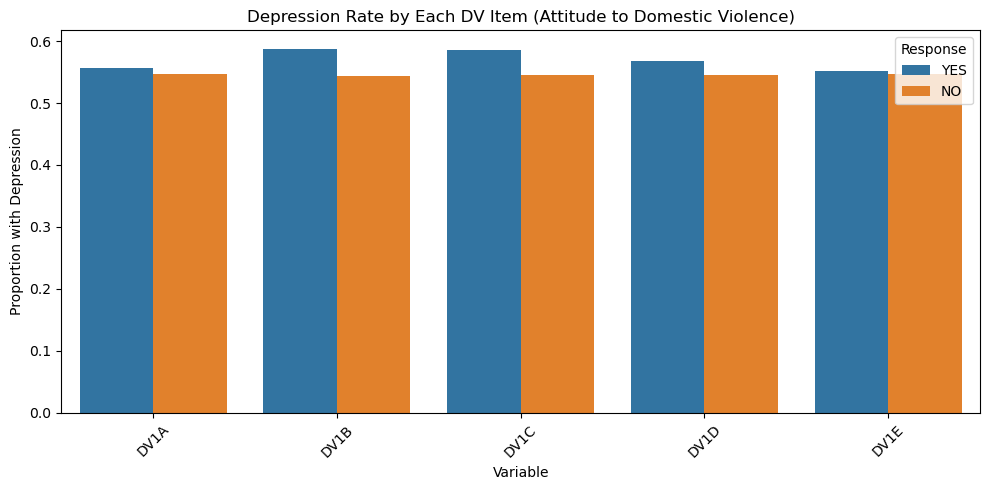

In [24]:
#Same as above
dv_cols = ['DV1A', 'DV1B', 'DV1C', 'DV1D', 'DV1E']
all_rates_dv = []
for col in dv_cols:
    if col in X_train.columns:
        all_rates_dv.extend(compute_depression_rate_by_response(X_train, col, y_train))

df_dv_rates = pd.DataFrame(all_rates_dv)

plt.figure(figsize=(10,5))
sns.barplot(data=df_dv_rates, x='Variable', y='DepressionRate', hue='Response')
plt.xticks(rotation=45)
plt.title('Depression Rate by Each DV Item (Attitude to Domestic Violence)')
plt.ylabel('Proportion with Depression')
plt.legend(title='Response')
plt.tight_layout()
plt.show()

Based on the above two graphs, in terms of views on children's corporal punishment and domestic violence, the group of children who usually answered 'YES' had a higher rate of depression than those who answered 'NO'. In addition, there is often a high correlation between different individual indicators of FCD2 and DV1, which increases the possibility of multicollinearity. Moreover, The situation affecting children's depression may not be one of these indicators. Maybe it is the combined effect of multiple aspects. Therefore, in feature engineering, FCD and DV1 can be summed separately to avoid too many variables affecting the subsequent analysis.

*7. Data Preprocessing and Feature Engineering*  
To ensure that the logistic regression model can converge stably and provide effective predictions, we have designed a multi-stage preprocessing workflow. This process mainly addresses three issues: inconsistent data formats, dimension redundancy, and missing value filling.  

Since the original survey data contains non-numeric symbols, such as 'DK' indicating "don't know", a custom preprocessing function was used to forcibly convert variables like WS4 (water collection time) and CL3 (children's working time) to numeric types, and abnormal inputs were set as missing values (NaN). In addition, the educational attainment (CB5A, WB6A) and life satisfaction (LS1) were standardized and aligned, and the data that did not conform to the grade definition were excluded.  

In order to reduce the complexity of the model and improve the statistical significance of the features, we combined the specific behaviors of corporal punishment (FCD2A-K) into a single continuous variable fcd_sum to quantify the severity of family discipline. Similarly, the attitudes towards domestic violence (DV1A-E) were also aggregated into dv_sum, serving as a proxy variable for the respondents' tolerance for violence.  

We have built a ColumnTransformer pipeline and implemented differentiated strategies for different variable types. Numeric: It uses median imputer and StandardScaler to balance the impact on weights. Ordinal classification: Encode academic qualifications and satisfaction levels using Ordinal encoder to retain their inherent degrees. Nominal classification: One-hot encoding is performed on unordered variables such as marital status. Binary: Directly fill the mode, maintaining its original 0/1 characteristic.


In [25]:
#Preprocessing function
def preprocess_features(X):
    X = X.copy()
    #Ensure CL3 and CL13 are numeric
    if 'CL3' in X.columns:
        X['CL3'] = pd.to_numeric(X['CL3'], errors='coerce')
    if 'CL13' in X.columns:
        X['CL13'] = pd.to_numeric(X['CL13'], errors='coerce')
        X['CL3_missing'] = X['CL3'].isnull().astype(int)
    #Convert WS4 to numeric
    if 'WS4' in X.columns:
        X['WS4'] = pd.to_numeric(X['WS4'], errors='coerce')
    
    #Clean up non-standard values in ordered variables
    cb5a_allowed = ['ECE', 'PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER']
    if 'CB5A' in X.columns:
        X['CB5A'] = X['CB5A'].where(X['CB5A'].isin(cb5a_allowed), np.nan)
    
    wb6a_allowed = ['PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER']
    if 'WB6A' in X.columns:
        X['WB6A'] = X['WB6A'].where(X['WB6A'].isin(wb6a_allowed), np.nan)
    
    ls1_allowed = ['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 
                   'SOMEWHAT HAPPY', 'VERY HAPPY']
    if 'LS1' in X.columns:
        X['LS1'] = X['LS1'].where(X['LS1'].isin(ls1_allowed), np.nan)
    
    #Deal with binary variables and bool variables, change into numbers
    binary_map = ['CB7', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15'] 
    for col in binary_map:
        if col in X.columns:
            if X[col].dtype == 'object':
                X[col] = X[col].map({'YES': 1, 'NO': 0}).fillna(0)
            elif X[col].dtype == 'bool':
                X[col] = X[col].astype(int)
    for col in ['CL2', 'CL12']:
        if col in X.columns:
            X[col] = X[col].astype(int)
    
    #Plus all FCD2A-K together
    fcd_cols = [f'FCD2{chr(ord("A")+i)}' for i in range(11)]
    existing_fcd = [c for c in fcd_cols if c in X.columns]
    if existing_fcd:
        fcd_sum = X[existing_fcd].apply(lambda col: col.map(lambda x: 1 if x == 'YES' else 0)).fillna(0).sum(axis=1)
        X['fcd_sum'] = fcd_sum
        X = X.drop(columns=existing_fcd)
    #Plus all DV1A-E together
    dv_cols = [f'DV1{chr(ord("A")+i)}' for i in range(5)]
    existing_dv = [c for c in dv_cols if c in X.columns]
    if existing_dv:
        dv_sum = X[existing_dv].apply(lambda col: col.map(lambda x: 1 if x == 'YES' else 0)).fillna(0).sum(axis=1)
        X['dv_sum'] = dv_sum
        X = X.drop(columns=existing_dv)
    return X
X_train_processed = preprocess_features(X_train)
X_test_processed = preprocess_features(X_test)
#Confirm all types of the columns
all_cols = X_train_processed.columns.tolist()
numeric_cols = ['CB3', 'CL3', 'CL13', 'CSURV', 'wscore', 'fcd_sum', 'dv_sum', 'WS4', 'CL3_missing']
numeric_cols = [c for c in numeric_cols if c in all_cols]

ordinal_cols = ['CB5A', 'WB6A', 'LS1']
ordinal_cols = [c for c in ordinal_cols if c in all_cols]

nominal_cols = ['MSTATUS']
nominal_cols = [c for c in nominal_cols if c in all_cols]

binary_cols = ['CB7', 'CL2', 'CL12', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15']
binary_cols = [c for c in binary_cols if c in all_cols]
print("numeric cols:", numeric_cols)
print("ordered cols:", ordinal_cols)
print("nominal cols:", nominal_cols)
print("binary cols:", binary_cols)
#Ordinal Encoding (The scores at different levels should be different)
ordinal_categories = []
if 'CB5A' in ordinal_cols:
    ordinal_categories.append(['ECE', 'PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER'])
if 'WB6A' in ordinal_cols:
    ordinal_categories.append(['PRIMARY', 'LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER'])
if 'LS1' in ordinal_cols:
    ordinal_categories.append(['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 
                               'SOMEWHAT HAPPY', 'VERY HAPPY'])

#Build pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('bin', binary_transformer, binary_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

#Evaluate
pipeline.fit(X_train_processed, y_train)
y_pred = pipeline.predict(X_test_processed)
y_prob = pipeline.predict_proba(X_test_processed)[:, 1]

print("\nclassification report:\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))

numeric cols: ['CB3', 'CL3', 'CL13', 'CSURV', 'wscore', 'fcd_sum', 'dv_sum', 'WS4', 'CL3_missing']
ordered cols: ['CB5A', 'WB6A', 'LS1']
nominal cols: ['MSTATUS']
binary cols: ['CB7', 'CL2', 'CL12', 'FCD5', 'MA3', 'TN1', 'WS7', 'WS15']

classification report:
               precision    recall  f1-score   support

           0       0.52      0.57      0.54      1181
           1       0.61      0.56      0.59      1431

    accuracy                           0.57      2612
   macro avg       0.57      0.57      0.56      2612
weighted avg       0.57      0.57      0.57      2612

AUC: 0.5908535506573626
confusion matrix:
 [[676 505]
 [629 802]]


# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project.ipynb